# 25_sensor_geometry_robustness.ipynb

Эксперименты на **неполной и изменённой геометрии датчиков** для уже обученных моделей.

Модели:
- **CNN baseline**
- **DeepONet v2**
- **FNO v1**
- **Safe Frozen Hybrid**

Проверяем:
1. **Receiver sector dropout**
2. **Source thinning**
3. **Receiver thinning**
4. **Receiver index shift**

На выходе:
- таблицы средних метрик;
- degradation curves;
- визуальные примеры.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Все модели используются только в режиме **inference**.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",

    "cnn_ckpt": "/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt",
    "deeponet_ckpt": "/workspace/reference_points/deeponet_v2_main/deeponet_best.pt",
    "fno_ckpt": "/workspace/reference_points/fno_v1/fno_best.pt",
    "safe_hybrid_ckpt": "/workspace/reference_points/safe_hybrid_frozen_deeponet_refiner_v1/safe_hybrid_best.pt",

    "run_name": "sensor_geometry_robustness",

    "enable_cnn": True,
    "mask_half_width": 2,
    "use_residual": True,

    "max_test_samples": None,
    "num_repeats": 3,

    "receiver_sector_dropout_fracs": [0.0, 0.05, 0.10, 0.20, 0.30],
    "active_source_counts": [16, 12, 8, 4],
    "active_receiver_counts": [256, 192, 128, 64],
    "receiver_shift_steps": [0, 4, 8, 16, 32],

    "vis_example_index": 0,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'cnn_ckpt': '/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt',
 'deeponet_ckpt': '/workspace/reference_points/deeponet_v2_main/deeponet_best.pt',
 'fno_ckpt': '/workspace/reference_points/fno_v1/fno_best.pt',
 'safe_hybrid_ckpt': '/workspace/reference_points/safe_hybrid_frozen_deeponet_refiner_v1/safe_hybrid_best.pt',
 'run_name': 'sensor_geometry_robustness',
 'enable_cnn': True,
 'mask_half_width': 2,
 'use_residual': True,
 'max_test_samples': None,
 'num_repeats': 3,
 'receiver_sector_dropout_fracs': [0.0, 0.05, 0.1, 0.2, 0.3],
 'active_source_counts': [16, 12, 8, 4],
 'active_receiver_counts': [256, 192, 128, 64],
 'receiver_shift_steps': [0, 4, 8, 16, 32],
 'vis_example_index': 0}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TEST_DIR = OUT_ROOT / "test"
CNN_CKPT_PATH = Path(CFG["cnn_ckpt"])
DEEPO_CKPT_PATH = Path(CFG["deeponet_ckpt"])
FNO_CKPT_PATH = Path(CFG["fno_ckpt"])
SAFE_CKPT_PATH = Path(CFG["safe_hybrid_ckpt"])

assert TEST_DIR.exists(), TEST_DIR
assert DEEPO_CKPT_PATH.exists(), DEEPO_CKPT_PATH
assert FNO_CKPT_PATH.exists(), FNO_CKPT_PATH
assert SAFE_CKPT_PATH.exists(), SAFE_CKPT_PATH
if CFG.get("enable_cnn", True):
    print("CNN checkpoint exists:", CNN_CKPT_PATH.exists(), "|", CNN_CKPT_PATH)

test_files = sorted(TEST_DIR.glob("*.npz"))
if CFG["max_test_samples"] is not None:
    test_files = test_files[:int(CFG["max_test_samples"])]

print("test samples used:", len(test_files))

CNN checkpoint exists: True | /workspace/reference_points/baseline_residual_v2_main/baseline_model.pt
test samples used: 800


In [5]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

train_dir = OUT_ROOT / "train"
all_c_values = []
for p in sorted(train_dir.glob("*.npz")):
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}

print("S, R:", S, R)
print("H, W:", H, W)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` через j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_3067/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 6.897179841995239 sec


## 2. Dataset

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTGeometryDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [10]:
ds_test = USCTGeometryDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_test[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7432032227516174 0.5520349740982056
{'path': '/workspace/usct_dataset_v2/test/sample_00000.npz', 'x_scale': 5060.05078125}


## 3. Model definitions and loading

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class SimpleUSCTBaseline(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, 32, stride=1)
        self.enc2 = ConvBlock(32, 64, stride=2)
        self.enc3 = ConvBlock(64, 128, stride=2)
        self.enc4 = ConvBlock(128, 128, stride=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 2 * 32, 128 * 12 * 12),
            nn.GELU(),
        )

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)
        z = self.enc4(z)
        z = self.flatten(z)
        z = self.fc(z)
        z = z.view(x.shape[0], 128, 12, 12)
        return self.dec(z)

class BranchEncoderV2(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        return self.net(x)

    def forward_with_features(self, x):
        feat = self.net[:12](x)
        vec = self.net[12:](feat)
        return vec, feat

class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]
        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [coords, torch.sin(y_proj), torch.cos(y_proj), torch.sin(x_proj), torch.cos(x_proj)]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2DV2(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(width=trunk_width, hidden=trunk_hidden, num_fourier_features=num_fourier_features, dropout=dropout)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(x.shape[0], 1, H, W)

In [12]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        scale = 1 / (in_channels * out_channels)
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        x = x.float()
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(
            batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1,
            dtype=torch.cfloat, device=x.device
        )
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))

class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8):
        super().__init__()
        self.padding = padding
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, H, device=device)
        xx = torch.linspace(-1.0, 1.0, W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)

        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])

        for block in self.blocks:
            x = block(x)

        if self.padding > 0:
            x = x[..., :H, :W]

        return self.head(x)

class SmallResidualRefiner(nn.Module):
    def __init__(self, feat_in=192, feat_decode=32):
        super().__init__()
        self.feat_decoder = nn.Sequential(
            nn.Conv2d(feat_in, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, feat_decode, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(1 + feat_decode, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, coarse, feat_map):
        h = self.feat_decoder(feat_map)
        h = torch.nn.functional.interpolate(h, size=coarse.shape[-2:], mode="bilinear", align_corners=False)
        z = torch.cat([coarse, h], dim=1)
        return self.refine(z)

class SafeFrozenHybrid(nn.Module):
    def __init__(self, backbone, feat_decode=32, max_refine_alpha=0.20, init_refine_alpha=0.03):
        super().__init__()
        self.backbone = backbone
        self.refiner = SmallResidualRefiner(feat_in=192, feat_decode=feat_decode)
        self.max_refine_alpha = float(max_refine_alpha)

        init_ratio = np.clip(init_refine_alpha / max_refine_alpha, 1e-4, 1 - 1e-4)
        init_raw = math.log(init_ratio / (1.0 - init_ratio))
        self.raw_alpha = nn.Parameter(torch.tensor(init_raw, dtype=torch.float32))

    def alpha(self):
        return self.max_refine_alpha * torch.sigmoid(self.raw_alpha)

    def forward(self, x, coords):
        with torch.no_grad():
            branch_vec, feat_map = self.backbone.branch.forward_with_features(x)
            trunk_vec = self.backbone.trunk(coords)
            coarse = torch.matmul(branch_vec, trunk_vec.t()) / math.sqrt(self.backbone.width) + self.backbone.bias
            coarse = coarse.view(x.shape[0], 1, H, W)

        residual = self.refiner(coarse, feat_map)
        return coarse + self.alpha() * residual

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_ckpt = torch.load(CNN_CKPT_PATH, map_location=device) if (CFG.get("enable_cnn", True) and CNN_CKPT_PATH.exists()) else None
deepo_ckpt = torch.load(DEEPO_CKPT_PATH, map_location=device)
fno_ckpt = torch.load(FNO_CKPT_PATH, map_location=device)
safe_ckpt = torch.load(SAFE_CKPT_PATH, map_location=device)

deepo_cfg = deepo_ckpt["config"]
fno_cfg = fno_ckpt["config"]
safe_cfg = safe_ckpt["config"]

yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords).to(device)

deepo = DeepONet2DV2(
    branch_width=deepo_cfg["branch_width"],
    trunk_width=deepo_cfg["trunk_width"],
    trunk_hidden=deepo_cfg["trunk_hidden"],
    num_fourier_features=deepo_cfg["num_fourier_features"],
    dropout=deepo_cfg["dropout"],
).to(device)
deepo.load_state_dict(deepo_ckpt["model_state_dict"], strict=True)
deepo.eval()

fno = FNO2dBaseline(
    width=fno_cfg["fno_width"],
    depth=fno_cfg["fno_depth"],
    modes1=fno_cfg["fno_modes_h"],
    modes2=fno_cfg["fno_modes_w"],
    padding=fno_cfg["fno_padding"],
).to(device)
fno.load_state_dict(fno_ckpt["model_state_dict"], strict=True)
fno.eval()

deepo_backbone = DeepONet2DV2(
    branch_width=safe_cfg["branch_width"],
    trunk_width=safe_cfg["trunk_width"],
    trunk_hidden=safe_cfg["trunk_hidden"],
    num_fourier_features=safe_cfg["num_fourier_features"],
    dropout=safe_cfg["dropout"],
).to(device)
deepo_backbone.load_state_dict(deepo_ckpt["model_state_dict"], strict=True)
deepo_backbone.eval()
for p in deepo_backbone.parameters():
    p.requires_grad = False

safe_hybrid = SafeFrozenHybrid(
    backbone=deepo_backbone,
    feat_decode=safe_cfg["feat_decode_channels"],
    max_refine_alpha=safe_cfg["max_refine_alpha"],
    init_refine_alpha=safe_cfg["init_refine_alpha"],
).to(device)
safe_hybrid.load_state_dict(safe_ckpt["model_state_dict"], strict=True)
safe_hybrid.eval()

models = {
    "DeepONet_v2": deepo,
    "FNO_v1": fno,
    "Safe_Hybrid": safe_hybrid,
}

if cnn_ckpt is not None:
    try:
        cnn = SimpleUSCTBaseline().to(device)
        state = cnn_ckpt["model_state_dict"] if isinstance(cnn_ckpt, dict) and "model_state_dict" in cnn_ckpt else cnn_ckpt
        cnn.load_state_dict(state, strict=True)
        cnn.eval()
        models["CNN_Baseline"] = cnn
        print("CNN baseline loaded successfully.")
    except Exception as e:
        print("CNN checkpoint found, but loading into SimpleUSCTBaseline failed.")
        print("Load error:", repr(e))
else:
    print("CNN baseline skipped: checkpoint not found or enable_cnn=False")

print("Loaded models:", list(models.keys()))

CNN baseline loaded successfully.
Loaded models: ['DeepONet_v2', 'FNO_v1', 'Safe_Hybrid', 'CNN_Baseline']


## 4. Geometry perturbations

In [14]:
def perturb_receiver_sector_dropout(x_np, frac, rng):
    if frac <= 0:
        return x_np.copy()
    x = x_np.copy()
    num_drop = int(round(R * frac))
    if num_drop <= 0:
        return x
    start = int(rng.integers(0, R))
    drop_idx = (np.arange(num_drop) + start) % R
    x[:, :, drop_idx] = 0.0
    return x

def perturb_source_thinning(x_np, active_count):
    x = x_np.copy()
    active_count = int(active_count)
    if active_count >= S:
        return x
    keep_idx = np.linspace(0, S - 1, active_count, dtype=int)
    drop_idx = np.setdiff1d(np.arange(S), keep_idx)
    x[:, drop_idx, :] = 0.0
    return x

def perturb_receiver_thinning(x_np, active_count):
    x = x_np.copy()
    active_count = int(active_count)
    if active_count >= R:
        return x
    keep_idx = np.linspace(0, R - 1, active_count, dtype=int)
    drop_idx = np.setdiff1d(np.arange(R), keep_idx)
    x[:, :, drop_idx] = 0.0
    return x

def perturb_receiver_shift(x_np, shift_steps):
    shift_steps = int(shift_steps)
    if shift_steps == 0:
        return x_np.copy()
    return np.roll(x_np, shift=shift_steps, axis=2).copy()

def apply_geometry_perturbation(x_np, perturbation_name, level, rng):
    if perturbation_name == "receiver_sector_dropout":
        return perturb_receiver_sector_dropout(x_np, level, rng)
    if perturbation_name == "source_thinning":
        return perturb_source_thinning(x_np, level)
    if perturbation_name == "receiver_thinning":
        return perturb_receiver_thinning(x_np, level)
    if perturbation_name == "receiver_shift":
        return perturb_receiver_shift(x_np, level)
    raise ValueError(perturbation_name)

## 5. Metrics and evaluation

In [15]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

def compute_metrics(pred, target, data_range):
    return {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }

@torch.no_grad()
def predict_model(model_name, x_np):
    xb = torch.from_numpy(x_np).unsqueeze(0).to(device)

    if model_name == "DeepONet_v2":
        pred = models[model_name](xb, coords_t)[0, 0].cpu().numpy()
    elif model_name == "FNO_v1":
        pred = models[model_name](xb)[0, 0].cpu().numpy()
    elif model_name == "Safe_Hybrid":
        pred = models[model_name](xb, coords_t)[0, 0].cpu().numpy()
    elif model_name == "CNN_Baseline":
        pred = models[model_name](xb)[0, 0].cpu().numpy()
    else:
        raise ValueError(model_name)

    return np.clip(pred, -1.0, 1.0)

def evaluate_under_geometry_perturbation(dataset, perturbation_name, levels, num_repeats=3, seed=123):
    rows = []
    data_range = float(stats["c_max"] - stats["c_min"])
    needs_randomness = perturbation_name in {"receiver_sector_dropout"}

    for model_name in models.keys():
        print("=" * 80)
        print("Model:", model_name, "| perturbation:", perturbation_name)

        for level in levels:
            rep_metrics = []
            effective_repeats = num_repeats if needs_randomness else 1

            for rep in range(effective_repeats):
                rng = np.random.default_rng(seed + rep + int(float(level) * 1000) + abs(hash(model_name + perturbation_name)) % 1000)
                metrics_list = []

                for idx in range(len(dataset)):
                    x, c, meta = dataset[idx]
                    x_np = x.numpy()
                    x_pert = apply_geometry_perturbation(x_np, perturbation_name, level, rng)

                    pred = predict_model(model_name, x_pert)
                    target = c[0].numpy()

                    pred_phys = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])
                    target_phys = denorm_c_from_minus1_1(target, stats["c_min"], stats["c_max"])

                    metrics_list.append(compute_metrics(pred_phys, target_phys, data_range))

                rep_df = pd.DataFrame(metrics_list)
                rep_metrics.append(rep_df.mean().to_dict())

            rep_df = pd.DataFrame(rep_metrics)
            row = {
                "model": model_name,
                "perturbation": perturbation_name,
                "level": float(level),
                "num_repeats": int(effective_repeats),
                "mse_mean": float(rep_df["mse"].mean()),
                "mse_std_over_repeats": float(rep_df["mse"].std()),
                "rmse_mean": float(rep_df["rmse"].mean()),
                "rmse_std_over_repeats": float(rep_df["rmse"].std()),
                "relative_l2_mean": float(rep_df["relative_l2"].mean()),
                "relative_l2_std_over_repeats": float(rep_df["relative_l2"].std()),
                "psnr_mean": float(rep_df["psnr"].mean()),
                "psnr_std_over_repeats": float(rep_df["psnr"].std()),
            }
            rows.append(row)

            print(
                f"level={level} | "
                f"rmse={row['rmse_mean']:.4f} ± {row['rmse_std_over_repeats']:.4f} | "
                f"rel_l2={row['relative_l2_mean']:.6f} | "
                f"psnr={row['psnr_mean']:.3f}"
            )

    return pd.DataFrame(rows)

## 6. Run experiments

In [16]:
df_sector_dropout = evaluate_under_geometry_perturbation(
    ds_test,
    "receiver_sector_dropout",
    CFG["receiver_sector_dropout_fracs"],
    CFG["num_repeats"],
    seed=111,
)

df_source_thinning = evaluate_under_geometry_perturbation(
    ds_test,
    "source_thinning",
    CFG["active_source_counts"],
    CFG["num_repeats"],
    seed=222,
)

df_receiver_thinning = evaluate_under_geometry_perturbation(
    ds_test,
    "receiver_thinning",
    CFG["active_receiver_counts"],
    CFG["num_repeats"],
    seed=333,
)

df_receiver_shift = evaluate_under_geometry_perturbation(
    ds_test,
    "receiver_shift",
    CFG["receiver_shift_steps"],
    CFG["num_repeats"],
    seed=444,
)

df_all = pd.concat([df_sector_dropout, df_source_thinning, df_receiver_thinning, df_receiver_shift], axis=0, ignore_index=True)
display(df_all.head())

Model: DeepONet_v2 | perturbation: receiver_sector_dropout
level=0.0 | rmse=13.8302 ± 0.0000 | rel_l2=0.009269 | psnr=23.338
level=0.05 | rmse=14.0805 ± 0.0061 | rel_l2=0.009437 | psnr=23.164
level=0.1 | rmse=14.4911 ± 0.0066 | rel_l2=0.009712 | psnr=22.894
level=0.2 | rmse=15.4795 ± 0.0421 | rel_l2=0.010376 | psnr=22.305
level=0.3 | rmse=16.8078 ± 0.0021 | rel_l2=0.011268 | psnr=21.569
Model: FNO_v1 | perturbation: receiver_sector_dropout
level=0.0 | rmse=17.3592 ± 0.0000 | rel_l2=0.011634 | psnr=21.347
level=0.05 | rmse=17.9866 ± 0.0083 | rel_l2=0.012054 | psnr=20.967
level=0.1 | rmse=18.6215 ± 0.0405 | rel_l2=0.012480 | psnr=20.610
level=0.2 | rmse=19.7705 ± 0.0518 | rel_l2=0.013251 | psnr=20.024
level=0.3 | rmse=20.8141 ± 0.0135 | rel_l2=0.013952 | psnr=19.544
Model: Safe_Hybrid | perturbation: receiver_sector_dropout
level=0.0 | rmse=13.6106 ± 0.0000 | rel_l2=0.009122 | psnr=23.526
level=0.05 | rmse=13.9314 ± 0.0122 | rel_l2=0.009337 | psnr=23.297
level=0.1 | rmse=14.4425 ± 0.0194

,model,perturbation,level,num_repeats,mse_mean,mse_std_over_repeats,rmse_mean,rmse_std_over_repeats,relative_l2_mean,relative_l2_std_over_repeats,psnr_mean,psnr_std_over_repeats
0,DeepONet_v2,receiver_sector_dropout,0.00,3,207.254257,0.000000,13.830151,2.175584e-15,0.009269,0.000000,23.338234,0.000000
1,DeepONet_v2,receiver_sector_dropout,0.05,3,214.098275,0.171033,14.080452,6.095071e-03,0.009437,0.000004,23.164041,0.004154
2,DeepONet_v2,receiver_sector_dropout,0.10,3,225.808854,0.290540,14.491065,6.586137e-03,0.009712,0.000004,22.894452,0.002392
3,DeepONet_v2,receiver_sector_dropout,0.20,3,256.845556,1.556353,15.479513,4.206867e-02,0.010376,0.000028,22.305332,0.021885
4,DeepONet_v2,receiver_sector_dropout,0.30,3,301.546380,0.100086,16.807756,2.131283e-03,0.011268,0.000001,21.569221,0.003483


## 7. Plots

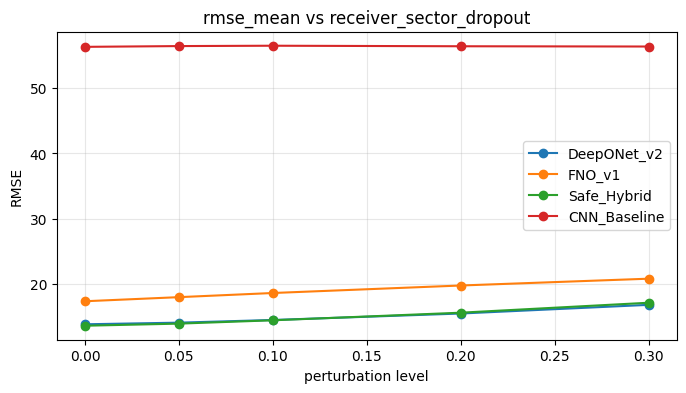

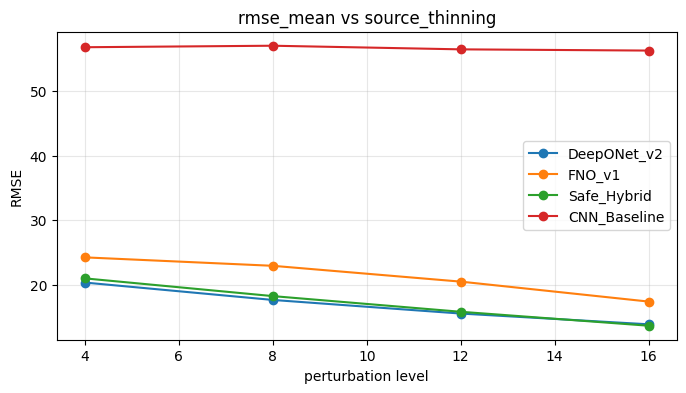

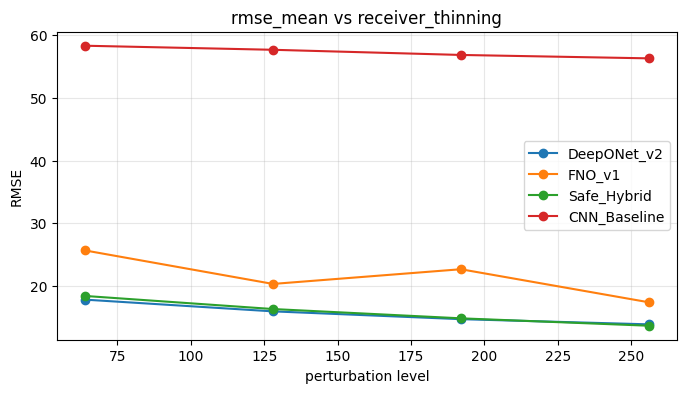

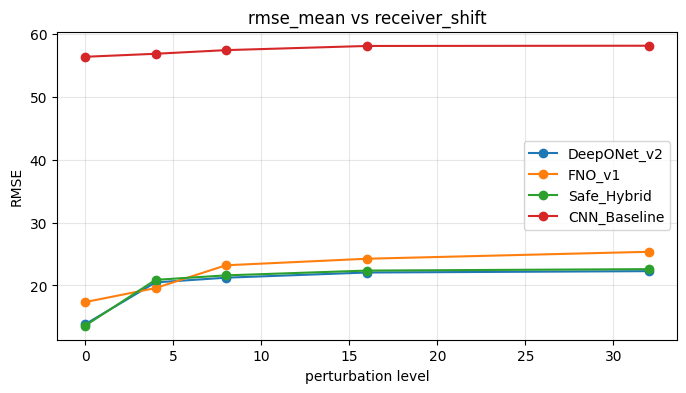

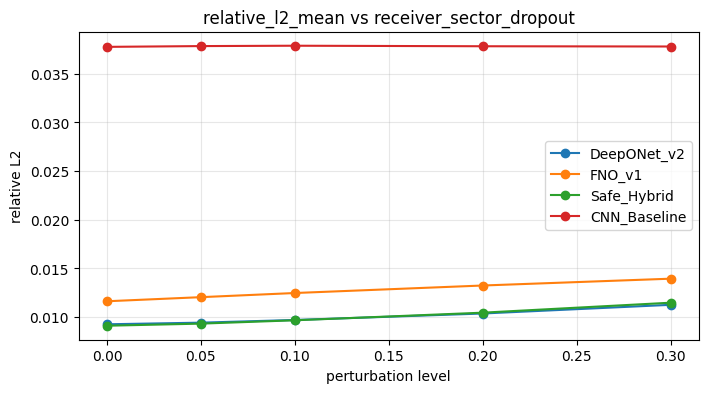

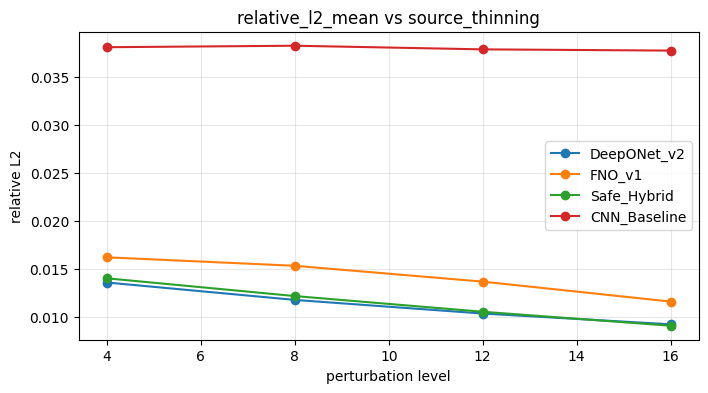

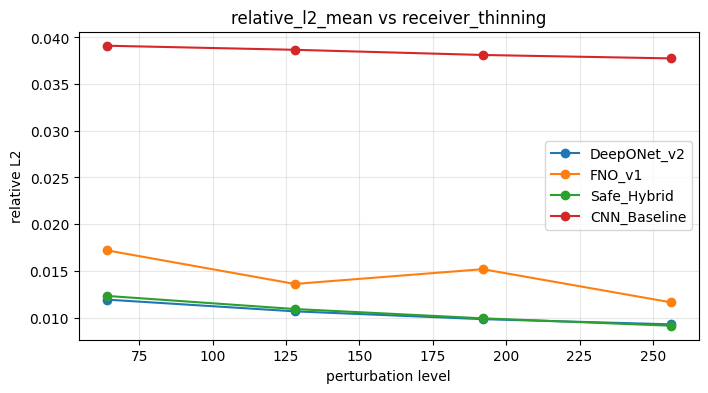

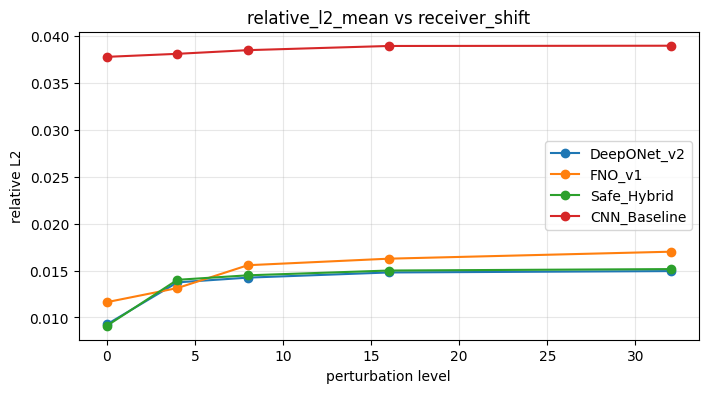

In [17]:
def plot_metric_curve(df, perturbation_name, metric="rmse_mean", ylabel=None):
    sub = df[df["perturbation"] == perturbation_name].copy()
    plt.figure(figsize=(8, 4))
    for model_name in sub["model"].unique():
        cur = sub[sub["model"] == model_name].sort_values("level")
        plt.plot(cur["level"], cur[metric], marker="o", label=model_name)
    plt.xlabel("perturbation level")
    plt.ylabel(ylabel or metric)
    plt.title(f"{metric} vs {perturbation_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metric_curve(df_all, "receiver_sector_dropout", "rmse_mean", "RMSE")
plot_metric_curve(df_all, "source_thinning", "rmse_mean", "RMSE")
plot_metric_curve(df_all, "receiver_thinning", "rmse_mean", "RMSE")
plot_metric_curve(df_all, "receiver_shift", "rmse_mean", "RMSE")

plot_metric_curve(df_all, "receiver_sector_dropout", "relative_l2_mean", "relative L2")
plot_metric_curve(df_all, "source_thinning", "relative_l2_mean", "relative L2")
plot_metric_curve(df_all, "receiver_thinning", "relative_l2_mean", "relative L2")
plot_metric_curve(df_all, "receiver_shift", "relative_l2_mean", "relative L2")

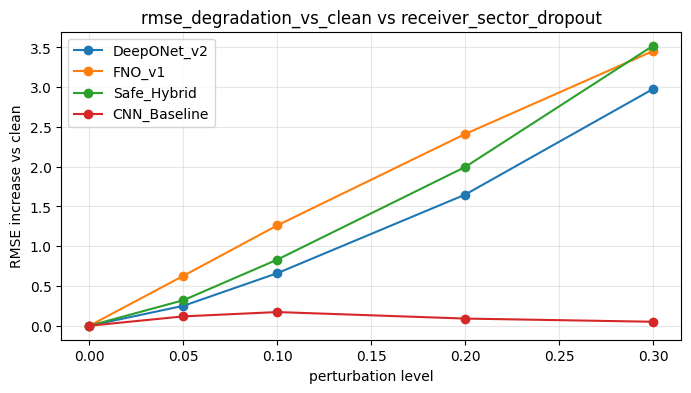

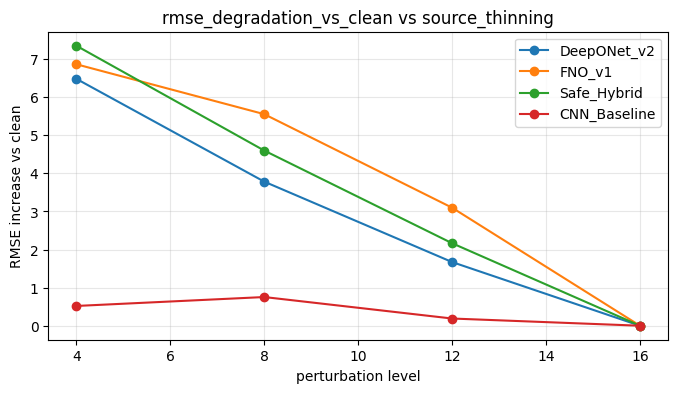

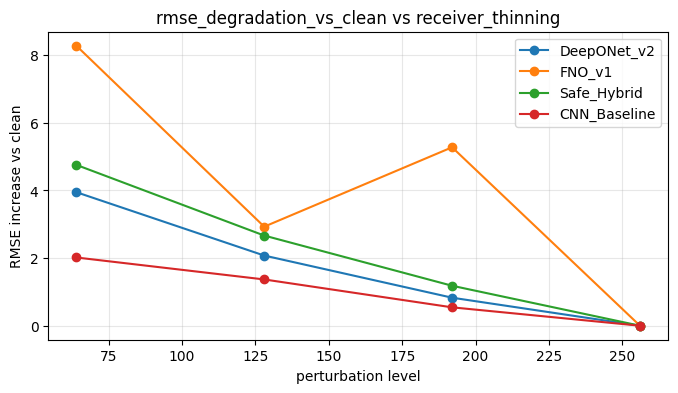

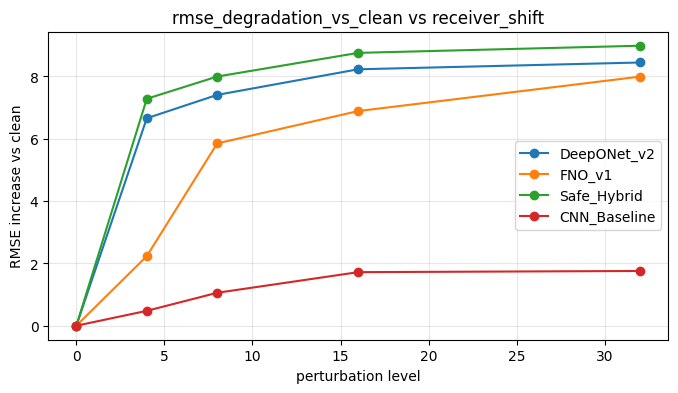

In [18]:
clean_rows = df_all[
    ((df_all["perturbation"] == "receiver_sector_dropout") & (df_all["level"] == 0.0)) |
    ((df_all["perturbation"] == "source_thinning") & (df_all["level"] == float(S))) |
    ((df_all["perturbation"] == "receiver_thinning") & (df_all["level"] == float(R))) |
    ((df_all["perturbation"] == "receiver_shift") & (df_all["level"] == 0.0))
][["model", "perturbation", "rmse_mean"]].copy()

clean_ref = clean_rows.groupby("model")["rmse_mean"].mean().to_dict()

df_all["rmse_degradation_vs_clean"] = df_all.apply(lambda r: r["rmse_mean"] - clean_ref[r["model"]], axis=1)
df_all["rmse_ratio_vs_clean"] = df_all.apply(lambda r: r["rmse_mean"] / clean_ref[r["model"]], axis=1)

plot_metric_curve(df_all, "receiver_sector_dropout", "rmse_degradation_vs_clean", "RMSE increase vs clean")
plot_metric_curve(df_all, "source_thinning", "rmse_degradation_vs_clean", "RMSE increase vs clean")
plot_metric_curve(df_all, "receiver_thinning", "rmse_degradation_vs_clean", "RMSE increase vs clean")
plot_metric_curve(df_all, "receiver_shift", "rmse_degradation_vs_clean", "RMSE increase vs clean")

## 8. Compact tables

In [19]:
def compact_pivot(df, perturbation_name, value_col):
    sub = df[df["perturbation"] == perturbation_name].copy()
    return sub.pivot(index="level", columns="model", values=value_col)

print("Receiver sector dropout / RMSE")
display(compact_pivot(df_all, "receiver_sector_dropout", "rmse_mean"))

print("Source thinning / RMSE")
display(compact_pivot(df_all, "source_thinning", "rmse_mean"))

print("Receiver thinning / RMSE")
display(compact_pivot(df_all, "receiver_thinning", "rmse_mean"))

print("Receiver shift / RMSE")
display(compact_pivot(df_all, "receiver_shift", "rmse_mean"))

Receiver sector dropout / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
0.00,56.325529,13.830151,17.359155,13.610649
0.05,56.442973,14.080452,17.986636,13.931443
0.10,56.497522,14.491065,18.621489,14.442523
0.20,56.415437,15.479513,19.770462,15.607061
0.30,56.375440,16.807756,20.814081,17.132020


Source thinning / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
4.0,56.844304,20.310243,24.221533,20.959583
8.0,57.078362,17.612042,22.911881,18.208218
12.0,56.514548,15.500992,20.456755,15.775828
16.0,56.325530,13.830151,17.359155,13.610649


Receiver thinning / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
64.0,58.342752,17.777642,25.636611,18.365553
128.0,57.693674,15.904827,20.286914,16.276332
192.0,56.869145,14.658490,22.634445,14.792295
256.0,56.325530,13.830151,17.359155,13.610649


Receiver shift / RMSE


model,CNN_Baseline,DeepONet_v2,FNO_v1,Safe_Hybrid
level,,,,
0.0,56.325530,13.830151,17.359155,13.610649
4.0,56.803686,20.490055,19.592616,20.895491
8.0,57.383265,21.239655,23.211172,21.608942
16.0,58.044919,22.061171,24.249013,22.368170
32.0,58.083028,22.279127,25.354186,22.597999


## 9. Visual examples

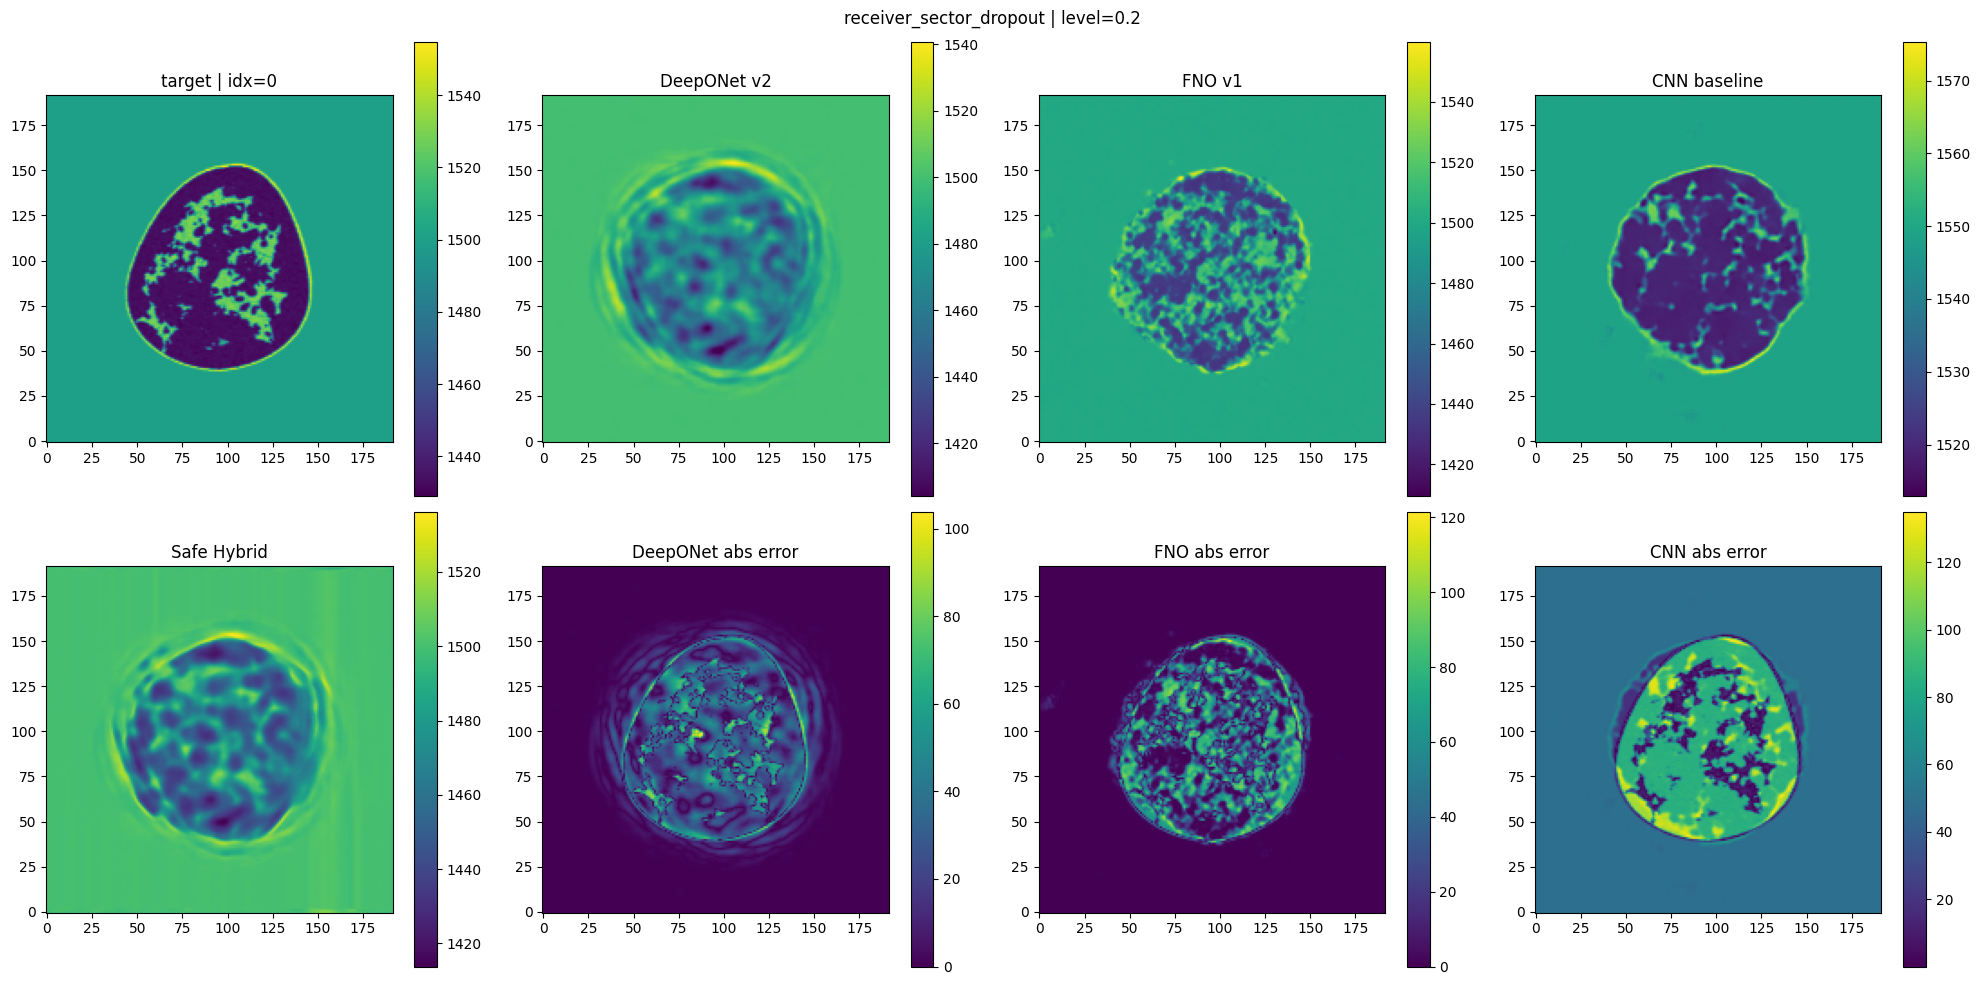

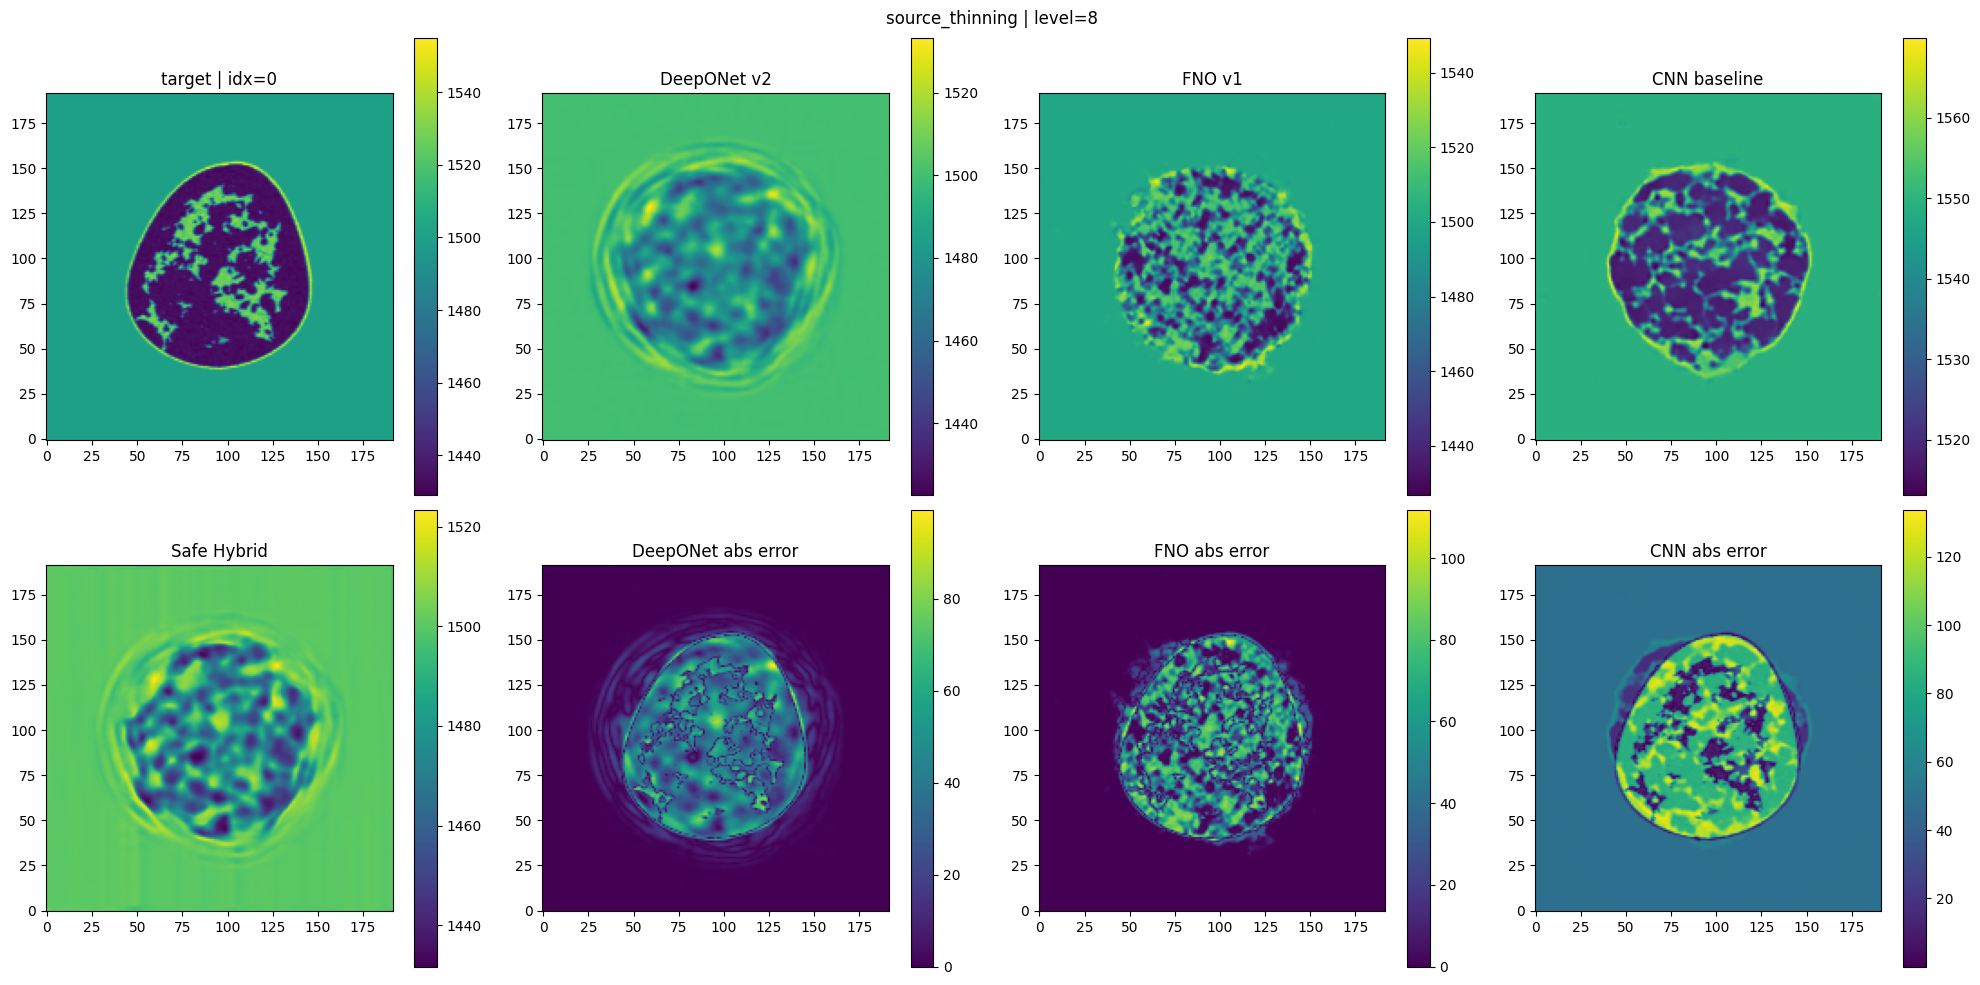

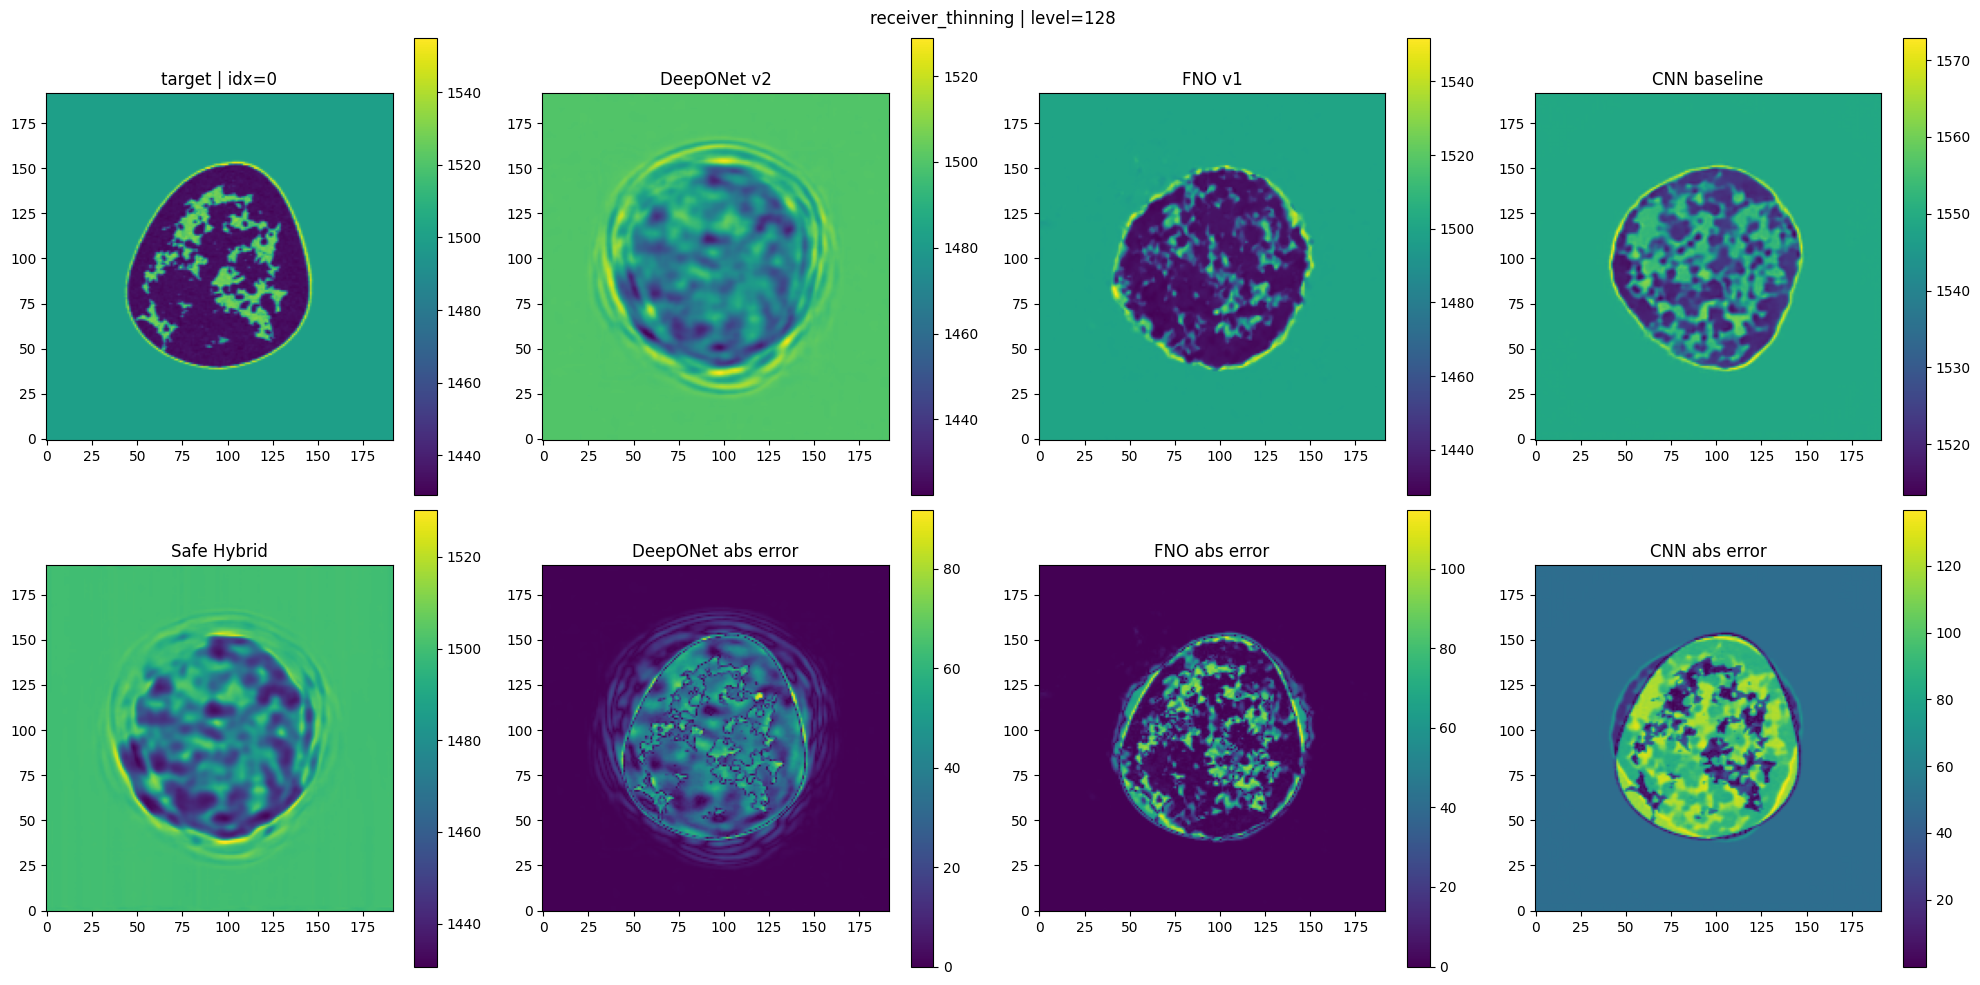

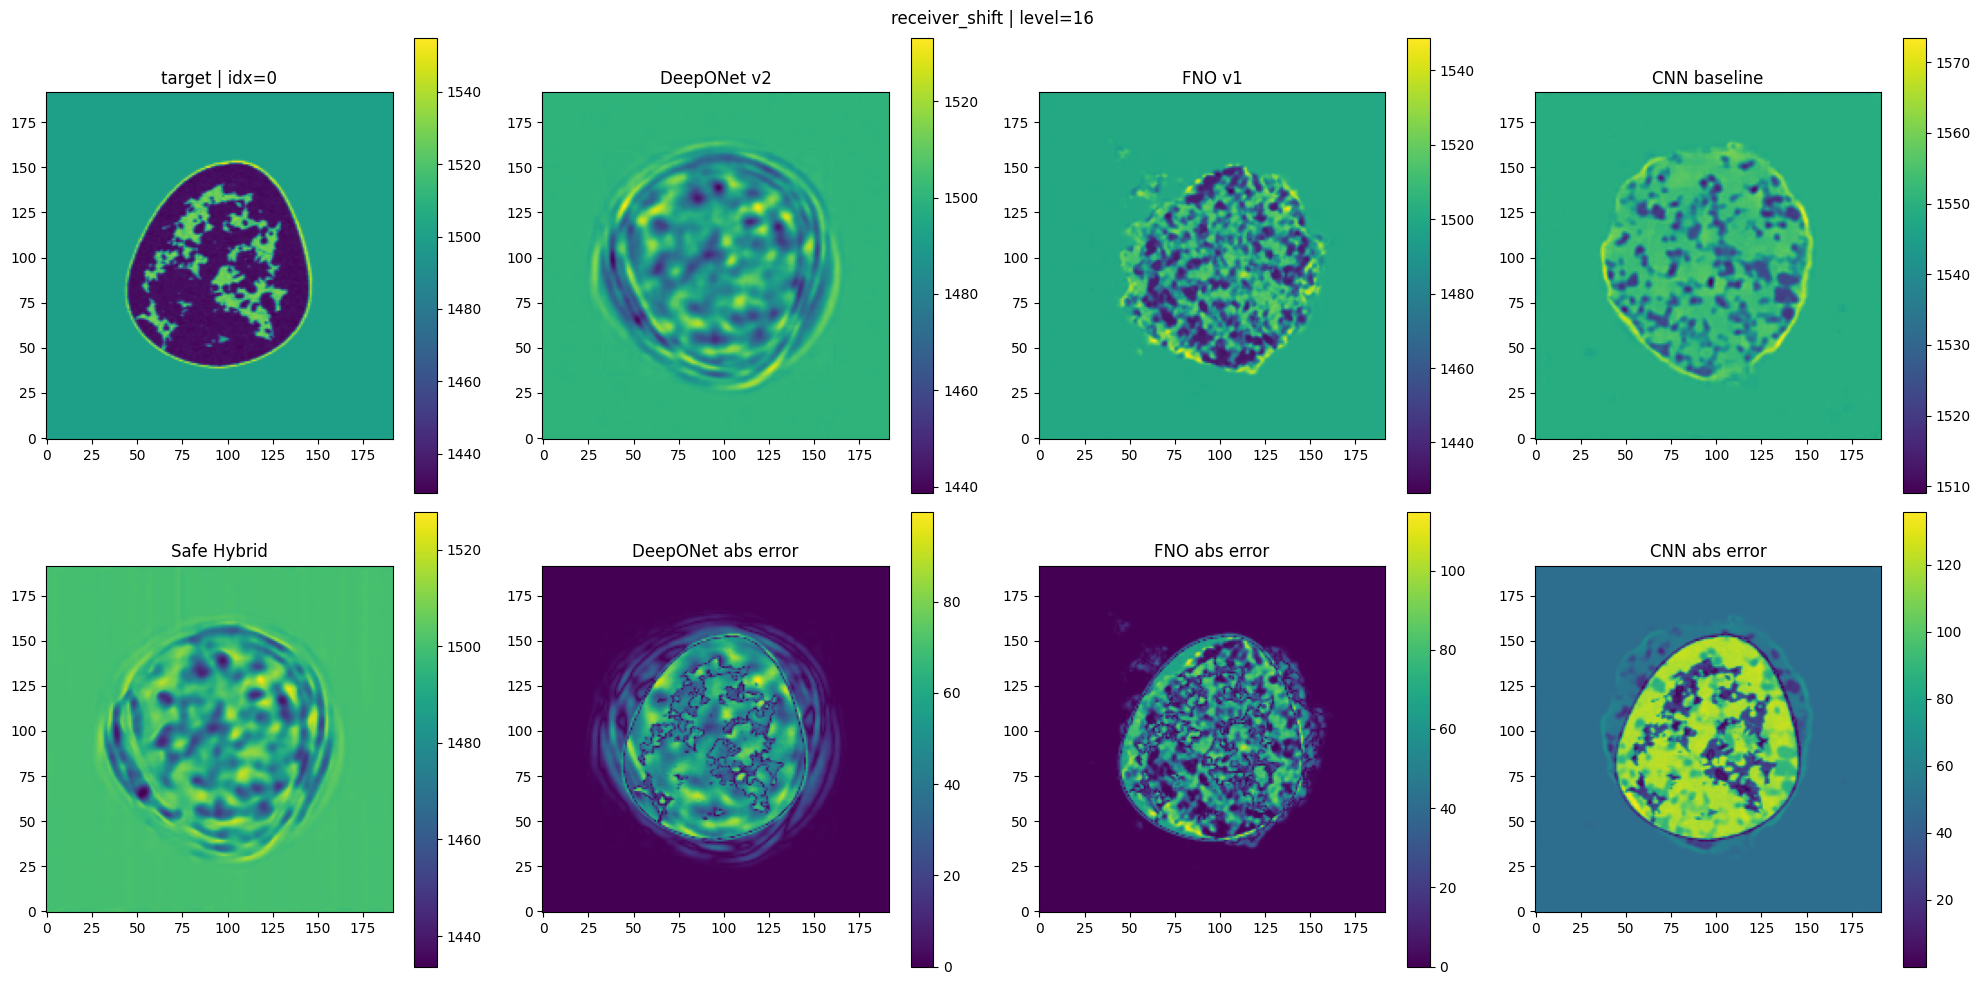

In [20]:
example_idx = int(CFG["vis_example_index"])
x_ex, c_ex, meta_ex = ds_test[example_idx]
x_ex_np = x_ex.numpy()
target = denorm_c_from_minus1_1(c_ex[0].numpy(), stats["c_min"], stats["c_max"])

def show_example_under_geometry(perturbation_name, level, title_suffix=""):
    rng = np.random.default_rng(12345)
    x_pert = apply_geometry_perturbation(x_ex_np, perturbation_name, level, rng)

    preds = {}
    for model_name in models.keys():
        pred = predict_model(model_name, x_pert)
        preds[model_name] = denorm_c_from_minus1_1(pred, stats["c_min"], stats["c_max"])

    has_cnn = "CNN_Baseline" in preds
    fig, ax = plt.subplots(2, 4 if has_cnn else 3, figsize=(20 if has_cnn else 16, 10))

    im0 = ax[0, 0].imshow(target, origin="lower")
    ax[0, 0].set_title(f"target | idx={example_idx}")
    plt.colorbar(im0, ax=ax[0, 0])

    im1 = ax[0, 1].imshow(preds["DeepONet_v2"], origin="lower")
    ax[0, 1].set_title("DeepONet v2")
    plt.colorbar(im1, ax=ax[0, 1])

    im2 = ax[0, 2].imshow(preds["FNO_v1"], origin="lower")
    ax[0, 2].set_title("FNO v1")
    plt.colorbar(im2, ax=ax[0, 2])

    if has_cnn:
        im3 = ax[0, 3].imshow(preds["CNN_Baseline"], origin="lower")
        ax[0, 3].set_title("CNN baseline")
        plt.colorbar(im3, ax=ax[0, 3])

    im4 = ax[1, 0].imshow(preds["Safe_Hybrid"], origin="lower")
    ax[1, 0].set_title("Safe Hybrid")
    plt.colorbar(im4, ax=ax[1, 0])

    im5 = ax[1, 1].imshow(np.abs(preds["DeepONet_v2"] - target), origin="lower")
    ax[1, 1].set_title("DeepONet abs error")
    plt.colorbar(im5, ax=ax[1, 1])

    im6 = ax[1, 2].imshow(np.abs(preds["FNO_v1"] - target), origin="lower")
    ax[1, 2].set_title("FNO abs error")
    plt.colorbar(im6, ax=ax[1, 2])

    if has_cnn:
        im7 = ax[1, 3].imshow(np.abs(preds["CNN_Baseline"] - target), origin="lower")
        ax[1, 3].set_title("CNN abs error")
        plt.colorbar(im7, ax=ax[1, 3])

    plt.suptitle(f"{perturbation_name} | level={level} {title_suffix}")
    plt.tight_layout()
    plt.show()

show_example_under_geometry("receiver_sector_dropout", 0.20)
show_example_under_geometry("source_thinning", 8)
show_example_under_geometry("receiver_thinning", 128)
show_example_under_geometry("receiver_shift", 16)

## 10. Save artifacts

In [21]:
RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

df_sector_dropout.to_csv(RUN_DIR / "receiver_sector_dropout_results.csv", index=False)
df_source_thinning.to_csv(RUN_DIR / "source_thinning_results.csv", index=False)
df_receiver_thinning.to_csv(RUN_DIR / "receiver_thinning_results.csv", index=False)
df_receiver_shift.to_csv(RUN_DIR / "receiver_shift_results.csv", index=False)
df_all.to_csv(RUN_DIR / "all_sensor_geometry_results.csv", index=False)

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "freq_hz": float(freq_hz),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/sensor_geometry_robustness
